# [LAB-07] 12-2. 교차분석 모듈화

## #01. 준비작업

### 1. 라이브러리 참조

In [1]:
from jussam import load_data
from helpers import *

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [2]:
origin = load_data("movie_view")
origin.head()

📚 OTT 서비스 업체 무비뷰의 회원 500명을 대상으로 조사된 가상의 데이터 셋

    field         description
--  ------------  --------------------------------------
 0  회원ID        회원 식별자 (인덱스)
 1  가입요일      가입한 요일(월~일)
 2  성별          남성 / 여성
 3  프리미엄전환  프리미엄 요금제 전환 여부(전환/미전환)
 4  지역          서울 / 부산 / 대구
 5  선호장르      액션 / 로맨스 / 다큐 / 예능
 6  베타그룹      신규 UI 베타테스트 그룹(A/B)
 7  베타만족      베타테스트 만족 여부(만족/불만족)



,가입요일,성별,지역,선호장르,프리미엄전환,베타그룹,베타만족
회원ID,,,,,,,
M0001,토,여성,부산,다큐,미전환,None,None
M0002,토,남성,서울,예능,미전환,None,None
M0003,금,여성,대구,다큐,미전환,None,None
M0004,토,남성,서울,로맨스,미전환,None,None
M0005,일,남성,대구,다큐,미전환,None,None


## #02. 모듈화 기능 확인

### 1. 적합도 검정 함수

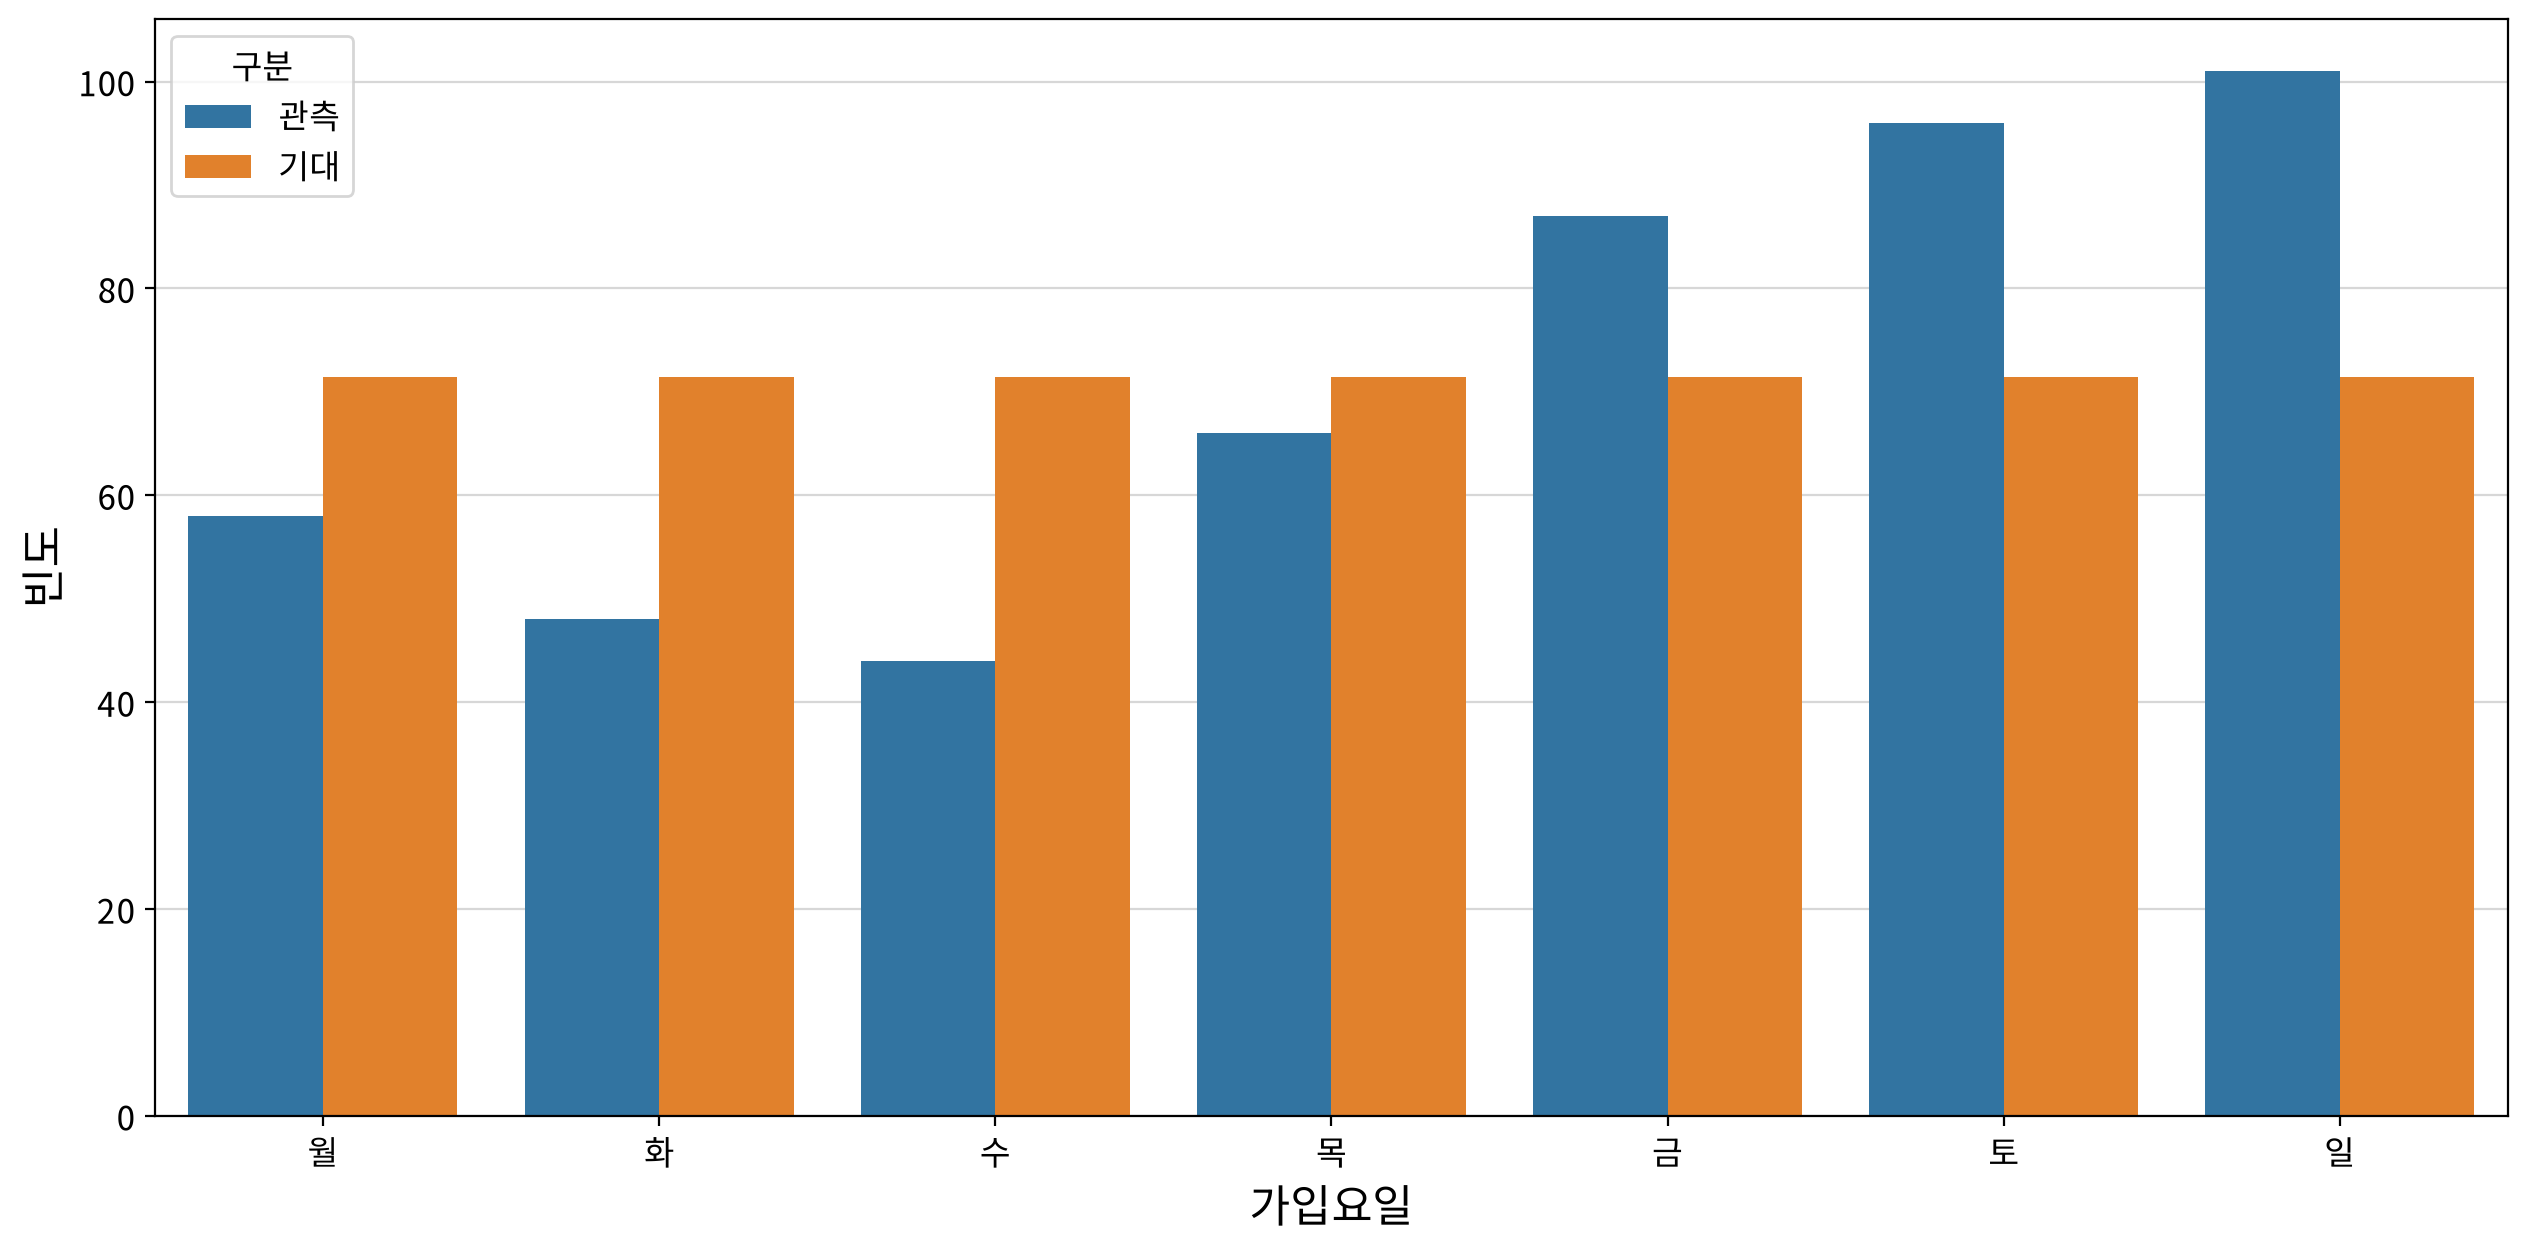

,chi2,dof,p-value,significant,effect(w),strength,min_expected,assumption
Chi-square goodness-of-fit,45.244,6,0.000,True,0.301,Moderate,71.430,True


In [3]:
my_stats.chi2_goodness_of_fit(origin, '가입요일', 
            order=['월', '화', '수', '목', '금', '토', '일'])

### 2. 독립성 검정 함수 확인

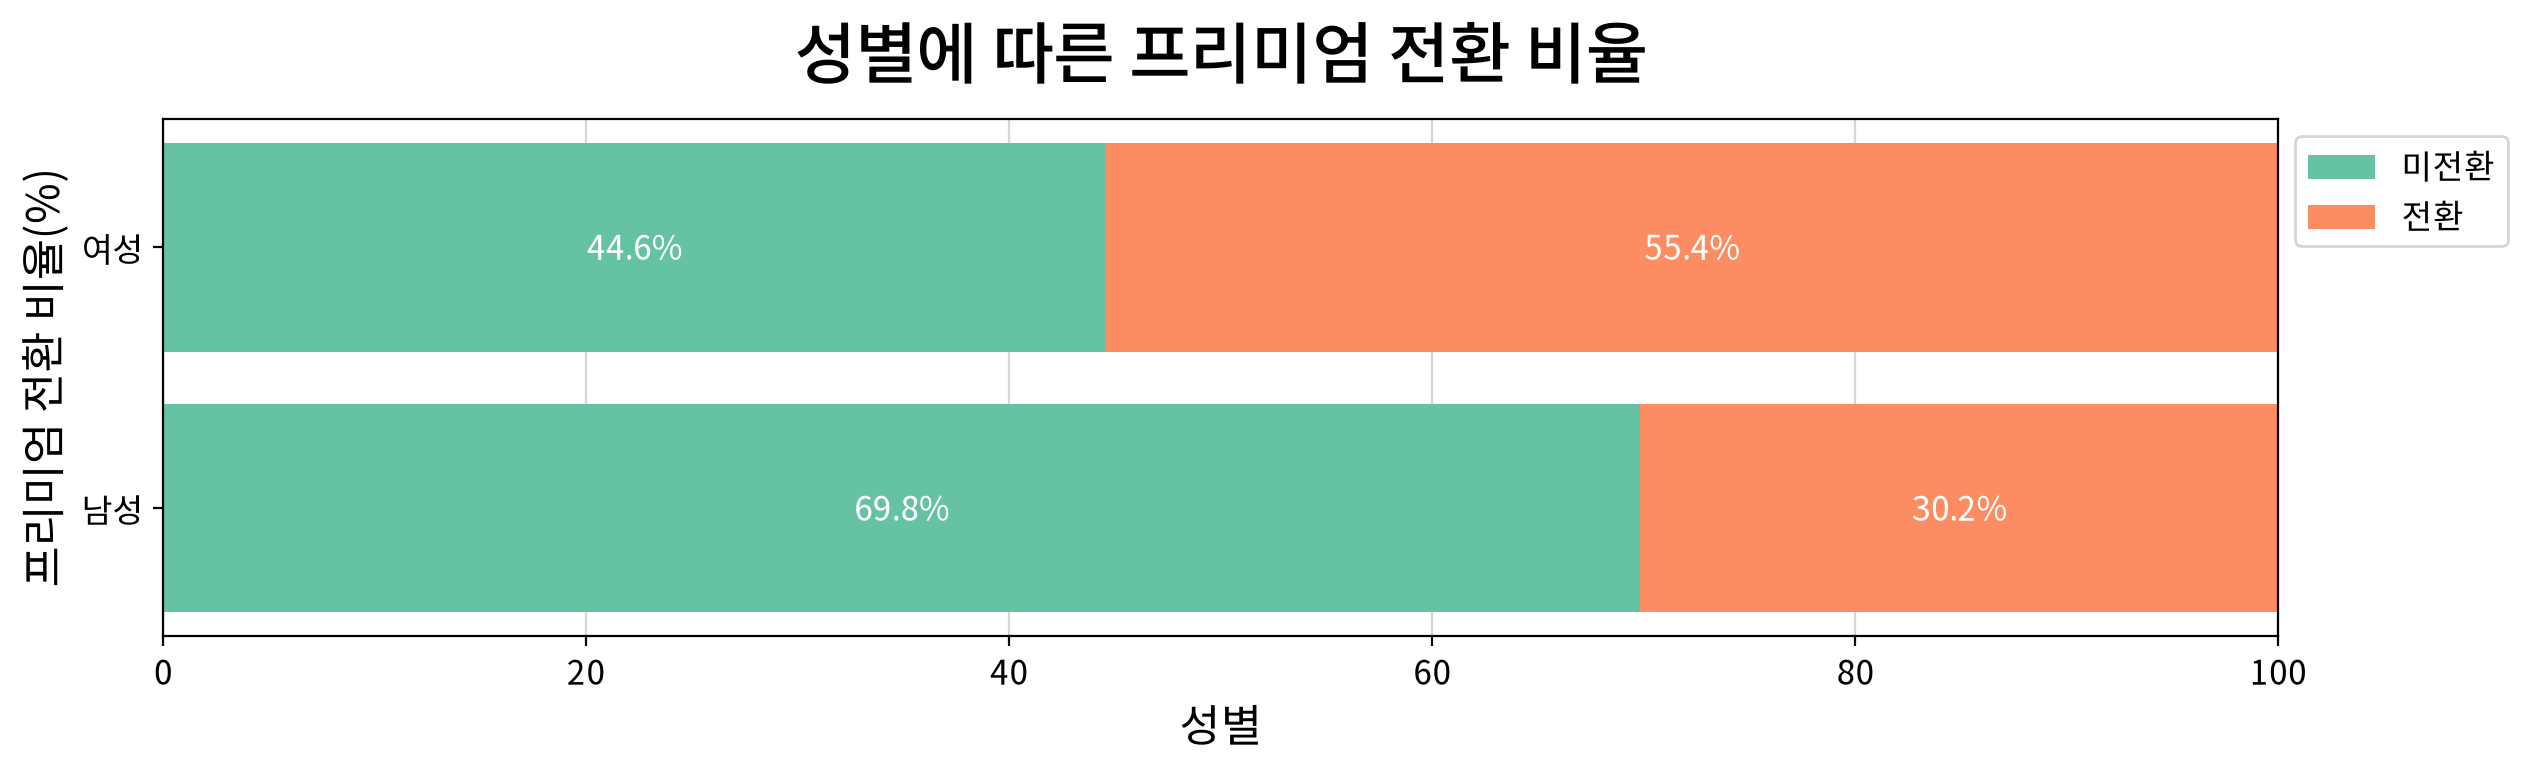

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
성별,프리미엄전환,Chi-square test of independence,31.453,1,0.000,True,0.251,Weak,104.540,True


In [4]:
my_stats.chi2_independence(origin, '성별', '프리미엄전환', 
            orient='h', palette='Set2', 
            title="성별에 따른 프리미엄 전환 비율", xlabel="성별", ylabel="프리미엄 전환 비율(%)", height=400)

### 3. 동질성 검정 함수 확인

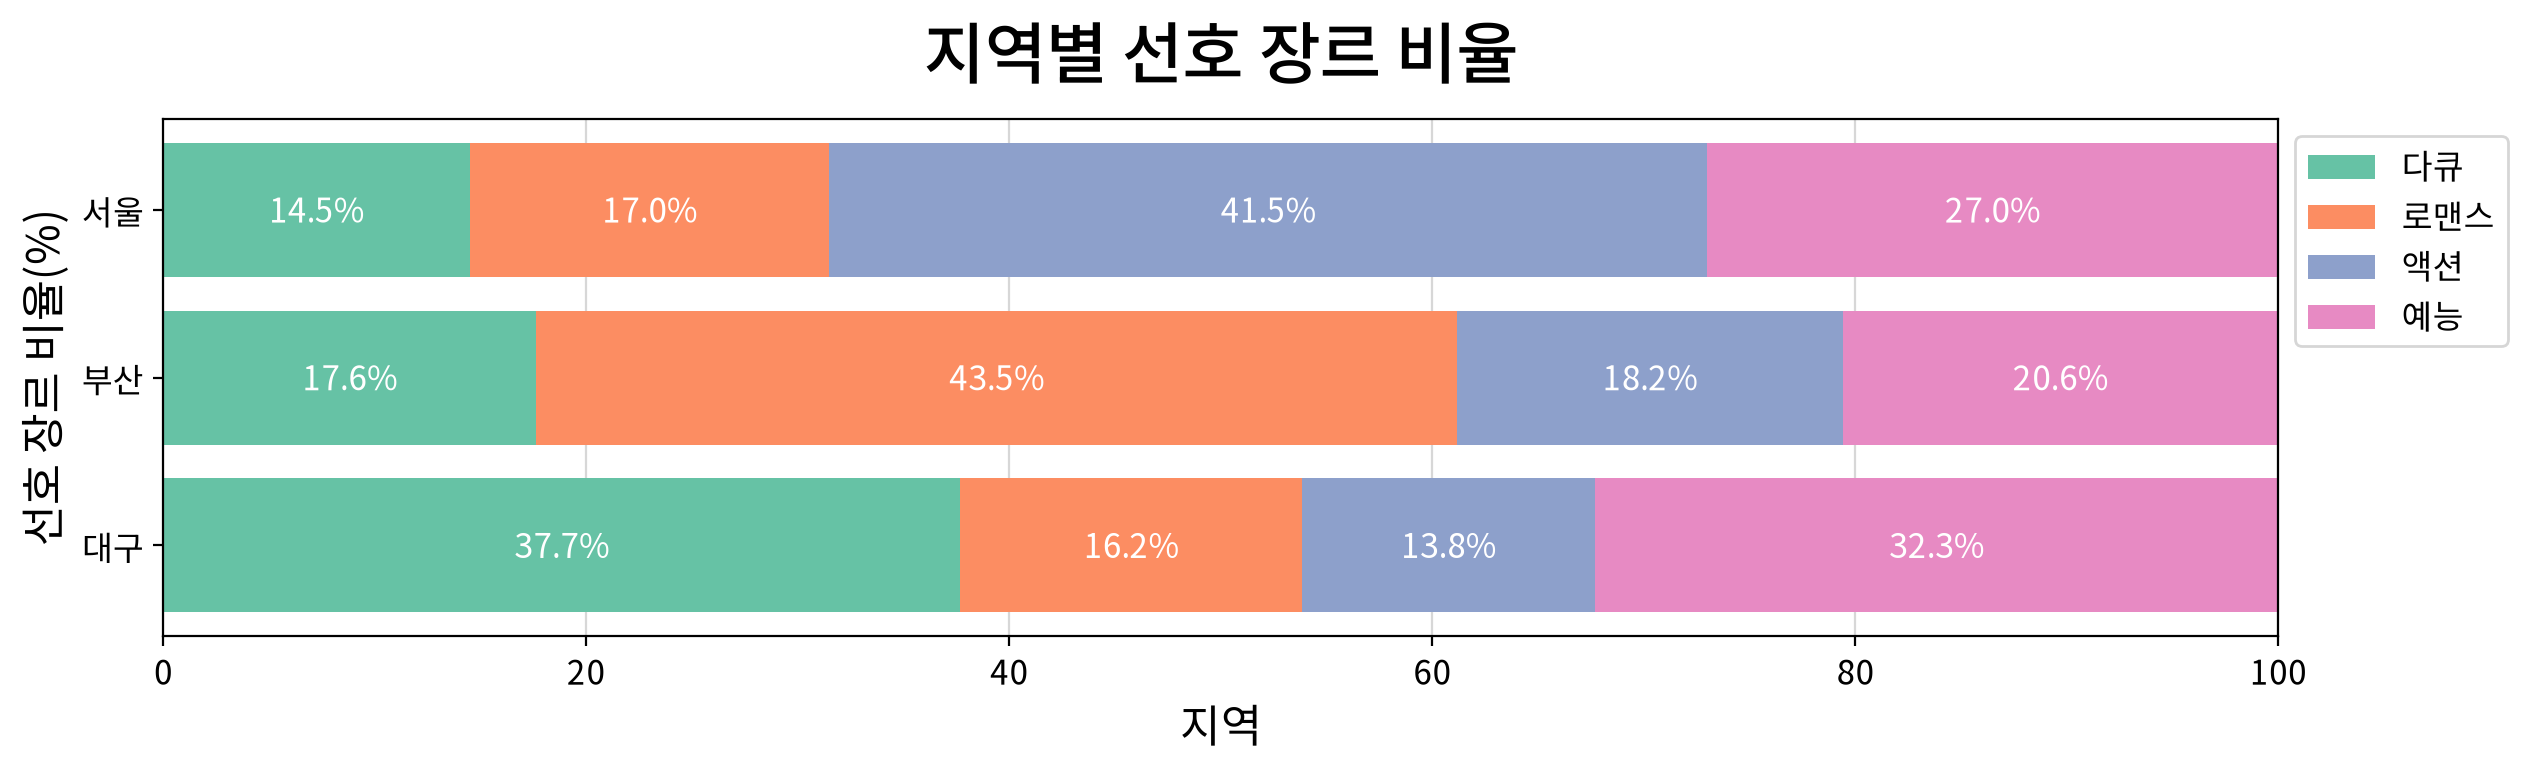

,,test,chi2,dof,p-value,significant,effect(V),strength,min_expected,assumption
row,col,,,,,,,,,
지역,선호장르,Chi-square test of homogeneity,86.156,6,0.000,True,0.293,Weak,28.080,True


In [5]:
my_stats.chi2_homogeneity(origin, '지역', '선호장르', 
            orient='h', palette='Set2', title="지역별 선호 장르 비율", xlabel="지역", ylabel="선호 장르 비율(%)", height=400)